# DiffMatte wall pipeline (+ SDMatte comparison)

Same job as `main_sd.ipynb`, different matting network: **DiffMatte**
([Diffusion for Natural Image Matting](https://arxiv.org/abs/2312.05915), ECCV 2024,
[code](https://github.com/YihanHu-2022/DiffMatte)) instead of SDMatte.

The two models are *not* interchangeable in what they accept:

| | SDMatte | DiffMatte |
|---|---|---|
| prompt types | trimap / mask / box / points | **trimap only** |
| backbone | Stable Diffusion U-Net (~1.3B) | plain ViT-S (29M) + tiny diffusion decoder |
| iterations | 1 step, denoise in latent space | N steps, denoise the **alpha** directly |
| VRAM @1024² | ~5 GB (fp16) | ~1.6 GB (fp32) |

DiffMatte has no visual-prompt mechanism at all, so the `mask` / `points` modes of `main_sd`
have no counterpart here. That is fine: `trimap` was the winning mode anyway, and it is the
only one that makes the comparison apples-to-apples.

**The trimap comes from `generate_trimap.make_trimap()`**, the same call `main_sd.ipynb` makes,
on the same source (`image2scene/<sample>/wall_mask.png`, the raw union of the API's wall masks
on the untouched photo). One code path, one set of defaults — only the network downstream
changes, so every difference in the output is the network's.

Reads `image2scene/<sample>/` (read-only), writes `users_diff/<sample>/`, and the last section
writes the head-to-head into **`compare_sd_diff/`**.

## detectron2
DiffMatte imports detectron2 for `LazyConfig` / `DetectionCheckpointer` / a few layers. detectron2
has no wheel for torch 2.12 + cu130 and builds a C++ extension this box cannot compile (no `g++`),
so `hq-mat/DiffMatte/d2shim/detectron2/` reimplements the handful of symbols the *inference* path
touches (`ShapeSpec`, `Conv2d`, `CNNBlockBase`, `get_norm`, `ImageList`,
`_assert_strides_are_log2_contiguous`) and the model is instantiated in plain Python instead of
through `LazyConfig`. The values below are transcribed from `configs/ViTS_1024.py` +
`configs/common/{model,difmatte,diffusion}.py`; the official checkpoint then loads with
**0 missing / 0 unexpected keys**, which is the check that the transcription is right.

## Imports & config

In [1]:
import os, sys, json, time, csv
from pathlib import Path
from functools import partial

import numpy as np
import cv2
import torch
import torch.nn as nn
from PIL import Image, ImageOps
import matplotlib.pyplot as plt

# The trimap generator, shared verbatim with main_sd.ipynb (and with the CLI batch mode of
# generate_trimap.py). Importing it is what guarantees the two notebooks cannot drift apart.
from generate_trimap import (wall_trimap, resolve_size, SIZE, METHOD, ITERATIONS,
                             FULL_RES, INNER_SIZE, FILL_HOLES, CUT_OBJECTS, CUT_DILATE)

ROOT = Path.cwd()
SRC_DIR = ROOT / "image2scene"          # original.jpg + wall_mask.png (written by run_api.py)
GD_DIR = ROOT / "users_gd"              # BiRefNet object masks, for TRIMAP_CUT_OBJECTS
SD_DIR = ROOT / "users_sd"              # main_sd.ipynb outputs -- the comparison baseline
OUT_DIR = ROOT / "users_diff"           # DiffMatte outputs land here
CMP_DIR = ROOT / "compare_sd_diff"      # head-to-head panels + metrics
DIFFMATTE_REPO = ROOT / "hq-mat" / "DiffMatte"
DIFFMATTE_CKPT = ROOT / "weights" / "DiffMatte" / "DiffMatte_ViTS_1024.pth"
device = "cuda" if torch.cuda.is_available() else "cpu"

# --- DiffMatte variant -------------------------------------------------------------------------
# ViTS(1024) is the best row in the paper's Composition-1k table (SAD 17.15) and the only one
# trained at 1024, which is the resolution main_sd runs SDMatte at. The other checkpoints
# (Res34 / SwinT / ViTS / ViTB) need their own configs -- see configs/*.py.
VARIANT = "ViTS_1024"
EMBED_DIM, DEPTH, NUM_HEADS = 384, 12, 6     # ViT-S, from configs/common/model.py
TRAIN_IMG_SIZE = 1024                        # configs/ViTS_1024.py: model.backbone.kwargs.img_size

# --- inference ---------------------------------------------------------------------------------
INFER_SIZE = 1024                # same as main_sd -> the two alphas are directly comparable.
                                 # DiffMatte is fully convolutional apart from the ViT position
                                 # embedding (interpolated), so other sizes work, but attention
                                 # cost grows ~quadratically in the global blocks (2,5,8,11).
DIFFUSION_STEPS = 1              # configs/ViTS_1024.py sets diffusion.steps = 1. Raising it makes
                                 # the decoder iterate (the paper's "ddim10"); each extra step is
                                 # another decoder pass, but the ViT features are cached, so it is
                                 # cheap (~0.1s/step). 10 is the paper's Composition-1k setting.
USE_DDIM = False                 # configs/ViTS_1024.py: difmatte.args["use_ddim"] = False.
                                 # True switches to the ddim sampler (needs DIFFUSION_STEPS > 1).
DIFFUSION_SCALE = 0.2            # configs/ViTS_1024.py: diffusion.scale
NOISE_SCHEDULE = "linear"        # configs/ViTS_1024.py: diffusion.noise_schedule
SEED = 0                         # the sampler starts from randn -> fix it or runs are not repeatable
DTYPE = torch.float32            # 1.6 GB at 1024², no need for fp16 (and the sampler is fp32 math)

TRIMAP_COMPOSITE = True          # keep the trimap's definite fg/bg verbatim, let DiffMatte decide
                                 # only the unknown band. Same switch as main_sd -- required for
                                 # the comparison, since users_sd alphas are composited too.
ALPHA_THRESH = 0.5               # alpha -> binary wall mask

# --- trimap: generate_trimap.make_trimap (IDENTICAL to main_sd.py -- the comparison depends on it)
TRIMAP_SRC = "wall_mask.png"     # raw union of the API's wall masks on the untouched photo
TRIMAP_SIZE = SIZE               # "0.75%" of the mask's average dimension, clamped to [3,30] px
TRIMAP_METHOD = METHOD           # "standard" = no fg erosion/dilation before the band
TRIMAP_ITERATIONS = ITERATIONS   # "0%" -> 1, and "standard" ignores it anyway
TRIMAP_FULL_RES = FULL_RES       # band at native res, one NEAREST downsample at the end
TRIMAP_INNER_SIZE = INNER_SIZE   # 0 = never eat wall into unknown
TRIMAP_FILL_HOLES = FILL_HOLES   # False = enclosed bg (TV, pictures) stays definite 0
TRIMAP_CUT_OBJECTS = CUT_OBJECTS # True = band pixels on the BiRefNet object mask -> definite 0
TRIMAP_CUT_DILATE = CUT_DILATE   # px @1024 the object mask is grown before that cut
OBJ_MASK_SRC = "object_mask_birefnet.png"   # read from GD_DIR/<sample>/

_difmatte = None                 # heavy model, filled by load_diffmatte()

## IO helpers (same conventions as `main_sd.py`)

In [2]:
def load_sample(sample_dir: Path):
    """original.jpg -> RGB PIL, EXIF-normalized IN MEMORY (fixes Orientation!=1 samples)."""
    return ImageOps.exif_transpose(Image.open(sample_dir / "original.jpg")).convert("RGB")


def mask_to_pil(mask) -> Image.Image:
    """Boolean/float mask -> 8-bit L image (255 = wall)."""
    return Image.fromarray((np.asarray(mask) > 0).astype(np.uint8) * 255, mode="L")

## Load DiffMatte
Built directly from the values in `configs/ViTS_1024.py` (see the header note on why `LazyConfig`
is bypassed). The checkpoint is a `DetectionCheckpointer` dict (`model` / `trainer` / `iteration`),
so `weights_only=False` is required to unpickle it, and the weights live under `["model"]` with a
`model.` / `decoder.` prefix that matches the `DifMatte(model=DifModel(...))` nesting.

In [3]:
def build_diffmatte():
    """Instantiate DifMatte(DifModel(ViT, DUNet), UniformGauss) -- no detectron2 config machinery."""
    for p in (DIFFMATTE_REPO / "d2shim", DIFFMATTE_REPO):    # shim first: it must win the import
        if str(p) not in sys.path:
            sys.path.insert(0, str(p))

    from modeling import create_backbone
    from modeling.decoder.DUNet import DUNet
    from modeling.meta_arch.difmodel import DifModel
    from modeling.meta_arch.difmatte import DifMatte
    from modeling.diffusion.script_utils import create_uniform_gaussian_diffusion

    backbone = create_backbone("ViT", dict(          # = configs/common/model.py backbone.kwargs
        in_chans=4,                                  # RGB + trimap
        img_size=TRAIN_IMG_SIZE,
        patch_size=16,
        embed_dim=EMBED_DIM,
        depth=DEPTH,
        num_heads=NUM_HEADS,
        drop_path_rate=0,
        window_size=14,
        mlp_ratio=4,
        qkv_bias=True,
        norm_layer=partial(nn.LayerNorm, eps=1e-6),
        window_block_indexes=[0, 1, 3, 4, 6, 7, 9, 10],   # 2, 5, 8, 11 stay global attention
        residual_block_indexes=[2, 5, 8, 11],
        use_rel_pos=True,
        out_feature="last_feat",
    ))
    model = DifModel(
        backbone=backbone,
        pixel_mean=[123.675 / 255., 116.280 / 255., 103.530 / 255.],
        pixel_std=[58.395 / 255., 57.120 / 255., 57.375 / 255.],
        decoder=DUNet(model_channels=32, emb_channels=32,
                      downsample_in=[7, 32, 64, 128],
                      upsample_in=[384, 256, 128, 64, 32]),
        backbone_in_channel=4,       # ViT sees image + raw trimap
        decoder_in_channel=7,        # decoder sees image + 3-way one-hot trimap + x_t
    )
    diffusion = create_uniform_gaussian_diffusion(   # = configs/common/diffusion.py (uniform branch)
        schedule_kwargs={}, time_difference=0.,
        scale=DIFFUSION_SCALE, steps=DIFFUSION_STEPS, uniform_timesteps=True,
        noise_schedule=NOISE_SCHEDULE, predict_xstart=True, criterion=None, jump_step=-1,
    )
    return DifMatte(model=model, diffusion=diffusion, input_format="RGB", size_divisibility=32,
                    args={"use_ddim": USE_DDIM, "batch_size": 1,
                          "image_size": INFER_SIZE, "clip_denoised": True})


def load_diffmatte():
    global _difmatte
    torch.set_float32_matmul_precision("high")

    _difmatte = build_diffmatte()
    ckpt = torch.load(DIFFMATTE_CKPT, map_location="cpu", weights_only=False)
    sd = ckpt["model"] if isinstance(ckpt, dict) and "model" in ckpt else ckpt
    missing, unexpected = _difmatte.load_state_dict(sd, strict=False)
    print(f"DiffMatte state_dict: {len(missing)} missing / {len(unexpected)} unexpected")
    assert not missing and not unexpected, "checkpoint does not match the transcribed config"
    _difmatte = _difmatte.to(device, DTYPE).eval()
    del ckpt, sd
    torch.cuda.empty_cache()

    n = sum(p.numel() for p in _difmatte.parameters()) / 1e6
    print(f"DiffMatte-{VARIANT} ready on {device} | {n:.1f}M params | {INFER_SIZE}px "
          f"| {DIFFUSION_STEPS} step(s) {'ddim' if USE_DDIM else 'ddpm'}")


load_diffmatte()

/home/krist/miniconda3/envs/birefnet/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/krist/miniconda3/envs/birefnet/lib/python3.10/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


DiffMatte state_dict: 0 missing / 0 unexpected


DiffMatte-ViTS_1024 ready on cuda | 29.0M params | 1024px | 1 step(s) ddpm


## Trimap — `generate_trimap.wall_trimap()`
Both notebooks call this same function, so the comparison measures the network and not the trimap.

`make_trimap` (the vendored `trimap_generator` algorithm) supplies the band: it dilates the binary
mask by a `(2*size+1)` square kernel and calls the resulting ring unknown, so **the band grows
OUTWARD only and the foreground is never eroded**. The definite foreground is therefore exactly
the API's wall mask — neither network can pull the wall boundary *inward*, only claim up to
`size` px beyond it.

`wall_trimap` wraps that with the wall-specific policy (all defaults live in `generate_trimap.py`):

- **`FULL_RES=True`** — build at the mask's native resolution, one `INTER_NEAREST` downsample of
  the finished 3-level trimap at the end. Load-bearing: `"0.75%"` is resolution-relative, so
  downsampling the mask first pins it to a constant 8 px and throws away the per-sample scaling.
- **`INNER_SIZE=0`** — never eat wall into unknown.
- **`FILL_HOLES=False`** — background enclosed by wall (a TV, a picture frame) is an *object*, so
  it stays definite 0 rather than being handed to the network as "you decide".
- **`CUT_OBJECTS=True`** — band pixels landing on the BiRefNet object mask are forced back to
  definite 0, so the buffer stays on true wall edges instead of running over furniture.

Net effect: unknown is a thin buffer at true wall boundaries and nothing else; objects are always
definite background.

In [4]:
def load_object_mask(sample_name, shape):
    """BiRefNet object mask for TRIMAP_CUT_OBJECTS, resized to `shape`. None if absent/disabled."""
    if not TRIMAP_CUT_OBJECTS:
        return None
    path = GD_DIR / sample_name / OBJ_MASK_SRC
    if not path.exists():
        print(f"  WARN: no {path}, band will not be cut against objects")
        return None
    obj = np.asarray(Image.open(path).convert("L"))
    if obj.shape[:2] != tuple(shape[:2]):
        obj = cv2.resize(obj, (shape[1], shape[0]), interpolation=cv2.INTER_NEAREST)
    return obj


_UNSET = object()


def build_trimap(sample_dir, size=INFER_SIZE, src=None,
                 band=None, method=None, iterations=None, object_mask=_UNSET, **kw):
    """image2scene surface mask -> trimap at (size,size): 0 = bg, 0.5 = unknown, 1 = fg."""
    src = src or TRIMAP_SRC

    path = sample_dir / src
    if not path.exists():
        raise FileNotFoundError(f"{path} -- run `python run_api.py` first")

    m = np.asarray(Image.open(path).convert("L"))
    return wall_trimap(
        m, out_size=size,
        size=TRIMAP_SIZE if band is None else band,
        method=TRIMAP_METHOD if method is None else method,
        iterations=TRIMAP_ITERATIONS if iterations is None else iterations,
        full_res=TRIMAP_FULL_RES, inner_size=TRIMAP_INNER_SIZE, fill_holes=TRIMAP_FILL_HOLES,
        object_mask=load_object_mask(sample_dir.name, m.shape), cut_dilate=TRIMAP_CUT_DILATE,
        name=sample_dir.name, **kw)


TRIMAP_LUT = np.array([0, 128, 255], np.uint8)     # bg / unknown / fg -> 8-bit preview


def trimap_to_pil(tri, size=None):
    """[0,0.5,1] trimap -> 8-bit L image (0 bg / 128 unknown / 255 fg), optionally resized."""
    im = Image.fromarray(TRIMAP_LUT[np.rint(tri * 2).astype(np.uint8)], mode="L")
    return im.resize(size, Image.NEAREST) if size else im


def load_trimap_file(path, size=INFER_SIZE):
    """Read a ready-made 3-level trimap -> [0, 0.5, 1] at (size,size).

    Accepts 127 or 128 for the unknown level: `generate_trimap.py` writes 127 (upstream
    trimap_generator's value), while the matting repos and this notebook's previews use 128."""
    tri = np.asarray(Image.open(path).convert("L"), np.float32)
    levels = set(np.unique(tri).tolist())
    if not levels <= {0.0, 127.0, 128.0, 255.0}:
        raise ValueError(f"{path}: expected a 0/127|128/255 trimap, got {len(levels)} levels "
                         f"({sorted(levels)[:6]}...). Use build_trimap() for a binary mask.")
    out = np.zeros_like(tri)
    out[(tri == 127) | (tri == 128)] = 0.5
    out[tri == 255] = 1.0
    return cv2.resize(out, (size, size), interpolation=cv2.INTER_NEAREST)

## DiffMatte inference
`DifMatte.forward` in eval mode runs the sampler (`ddpm_sample` / `ddim_sample` in
`modeling/diffusion/uniform_gauss.py`), which needs only `{"image", "trimap"}` in the batch dict —
it injects `x_t` (the noised alpha) and `timestep` itself on every step, and caches the ViT
features between steps so extra steps cost a decoder pass only.

Preprocessing follows `DifModel.preprocess_inputs`, which is where DiffMatte differs from SDMatte:
the image is **[0,1], not [-1,1]** (it does its own ImageNet mean/std normalization internally),
and the trimap stays at **0 / 0.5 / 1** (the model one-hots it for the decoder and concatenates the
raw value as the ViT's 4th channel). Passing SDMatte's `*2-1` convention here would be silently
wrong, so nothing is pre-scaled below.

The sampler seeds from `torch.randn`, so `SEED` is fixed — otherwise two runs on the same sample
disagree by a few tenths of a percent and the comparison numbers wobble.

In [5]:
@torch.no_grad()
def _diffmatte_run(image: Image.Image, trimap01, size=INFER_SIZE, seed=SEED):
    """One DiffMatte sampling run -> float alpha (H, W) in [0,1] at the image's original size.
    trimap01: [0, 0.5, 1] float trimap at (size, size)."""
    w, h = image.size
    im = cv2.resize(np.asarray(image, np.float32) / 255.0, (size, size),
                    interpolation=cv2.INTER_LINEAR)

    if seed is not None:
        torch.manual_seed(seed)
    data = {
        "image": torch.from_numpy(im.transpose(2, 0, 1))[None].to(device, DTYPE),
        "trimap": torch.from_numpy(trimap01)[None, None].to(device, DTYPE),
    }
    alpha = _difmatte(data) / 255.0            # returns a (size,size) float numpy array in 0..255
    torch.cuda.empty_cache()
    return cv2.resize(alpha.astype(np.float32), (w, h), interpolation=cv2.INTER_LINEAR)


def diffmatte_alpha(image, trimap, composite=None):
    """Trimap -> alpha. With `composite`, only the unknown band keeps the network's output: the
    definite fg/bg of the full-resolution trimap wins over the 1024-px prediction (same contract
    as `sdmatte_alpha_trimap` in main_sd, so the two alphas stay comparable)."""
    alpha = _diffmatte_run(image, trimap)
    if TRIMAP_COMPOSITE if composite is None else composite:
        tri = np.asarray(trimap_to_pil(trimap, image.size), np.float32) / 255.0   # 0 / ~0.5 / 1
        alpha = np.where(tri > 0.9, 1.0, np.where(tri < 0.1, 0.0, alpha)).astype(np.float32)
    return alpha

## Full pipeline

In [6]:
def run_pipeline_diff(sample_dir: Path, thresh=ALPHA_THRESH):
    """DiffMatte wall alpha for one sample. Reads image2scene/<sample>/, writes users_diff/<sample>/.

    Writes `wall_alpha_diffmatte.png` (composited), `wall_alpha_diffmatte_raw.png` (network output
    before compositing -- kept because the composite hides what the model actually predicted inside
    the definite regions), `wall_mask_diffmatte.png`, `trimap.png`, `overlay.png`, `prompt.json`,
    `time.txt`."""
    out_dir = OUT_DIR / sample_dir.name
    out_dir.mkdir(parents=True, exist_ok=True)
    img = load_sample(sample_dir)

    timings, t0 = {}, time.time()

    trimap = build_trimap(sample_dir)
    timings["trimap"] = time.time() - t0

    t1 = time.time()
    raw = _diffmatte_run(img, trimap)
    timings["diffmatte"] = time.time() - t1

    if TRIMAP_COMPOSITE:
        tri_full = np.asarray(trimap_to_pil(trimap, img.size), np.float32) / 255.0
        alpha = np.where(tri_full > 0.9, 1.0, np.where(tri_full < 0.1, 0.0, raw)).astype(np.float32)
    else:
        alpha = raw
    wall = alpha >= thresh

    Image.fromarray((alpha * 255).astype(np.uint8), "L").save(out_dir / "wall_alpha_diffmatte.png")
    Image.fromarray((raw * 255).astype(np.uint8), "L").save(out_dir / "wall_alpha_diffmatte_raw.png")
    mask_to_pil(wall).save(out_dir / "wall_mask_diffmatte.png")
    trimap_to_pil(trimap, img.size).save(out_dir / "trimap.png")
    overlay = np.asarray(img).astype(np.float32)
    overlay[wall] = 0.5 * overlay[wall] + 0.5 * np.array((0, 130, 200), np.float32)
    Image.fromarray(overlay.clip(0, 255).astype(np.uint8)).save(out_dir / "overlay.png")
    (out_dir / "prompt.json").write_text(json.dumps(
        {"model": f"DiffMatte-{VARIANT}", "steps": DIFFUSION_STEPS,
         "sampler": "ddim" if USE_DDIM else "ddpm", "scale": DIFFUSION_SCALE, "seed": SEED,
         "infer_size": INFER_SIZE, "trimap_composite": TRIMAP_COMPOSITE,
         "trimap_generator": "generate_trimap.wall_trimap", "trimap_src": TRIMAP_SRC,
         "trimap_cfg": {"size": TRIMAP_SIZE, "method": TRIMAP_METHOD,
                        "iterations": TRIMAP_ITERATIONS, "full_res": TRIMAP_FULL_RES,
                        "inner_size": TRIMAP_INNER_SIZE, "fill_holes": TRIMAP_FILL_HOLES,
                        "cut_objects": TRIMAP_CUT_OBJECTS, "cut_dilate": TRIMAP_CUT_DILATE}},
        indent=1))

    timings["total"] = time.time() - t0
    (out_dir / "time.txt").write_text(
        "\n".join(f"{k:<16s} {v:8.2f}s" for k, v in timings.items()) + "\n")
    print(f"  TOTAL {timings['total']:.1f}s -> {out_dir}")

    return {"img": img, "alpha": alpha, "raw": raw, "wall": wall, "trimap": trimap,
            "timings": timings}

## Run on one sample

In [7]:
SAMPLE = "user_11"          # any folder under image2scene/

res = run_pipeline_diff(SRC_DIR / SAMPLE)
print(f"wall = {100 * res['wall'].mean():.1f}% of frame")

ddpm sampling loop time step:   0%|          | 0/1 [00:00<?, ?it/s]

ddpm sampling loop time step: 100%|██████████| 1/1 [00:00<00:00,  2.06it/s]

ddpm sampling loop time step: 100%|██████████| 1/1 [00:00<00:00,  2.06it/s]

  TOTAL 8.4s -> /home/krist/works/refine-mask/users_diff/user_11
wall = 56.1% of frame


## Result: trimap, alpha, binary wall, overlay

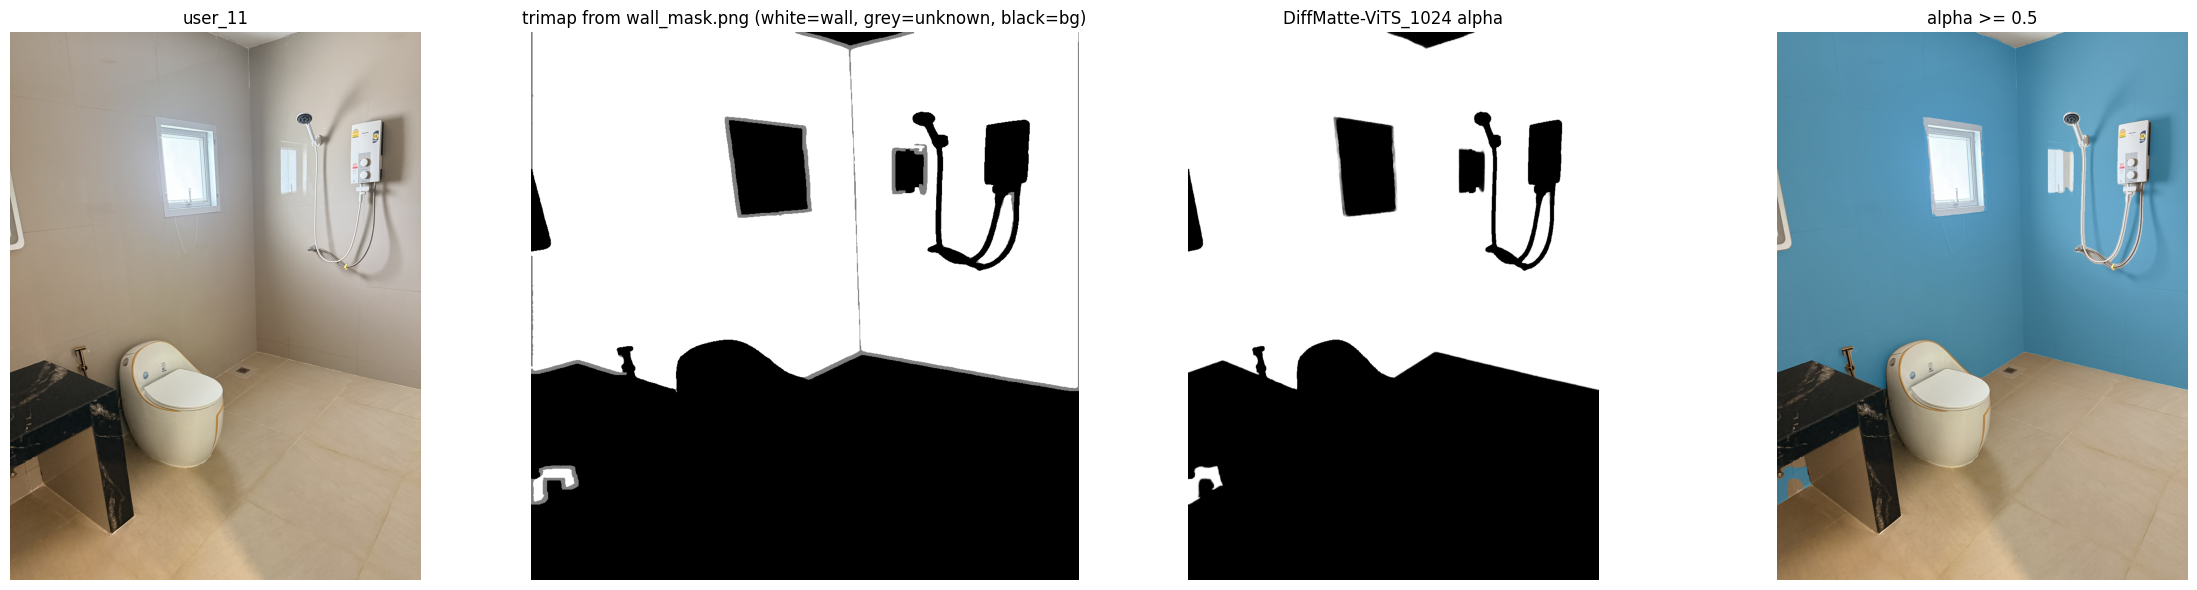

In [8]:
fig, ax = plt.subplots(1, 4, figsize=(24, 6))
ax[0].imshow(res["img"]);                                     ax[0].set_title(SAMPLE)
ax[1].imshow(res["trimap"], cmap="gray", vmin=0, vmax=1)
ax[1].set_title(f"trimap from {TRIMAP_SRC} (white=wall, grey=unknown, black=bg)")
ax[2].imshow(res["alpha"], cmap="gray", vmin=0, vmax=1)
ax[2].set_title(f"DiffMatte-{VARIANT} alpha")
ax[3].imshow(Image.open(OUT_DIR / SAMPLE / "overlay.png"))
ax[3].set_title(f"alpha >= {ALPHA_THRESH}")
for a in ax:
    a.axis("off")
plt.tight_layout()

## Batch over every sample that has an `image2scene` wall mask

In [9]:
for d in sorted(SRC_DIR.iterdir()):
    if d.is_dir() and (d / "original.jpg").exists():
        if not (d / TRIMAP_SRC).exists():
            print(f"{d.name}: no {TRIMAP_SRC}, skipped (run `python run_api.py`)"); continue
        print(d.name)
        try:
            run_pipeline_diff(d)
        except ValueError as e:      # make_trimap rejects all-black / all-white / grayscale masks
            print(f"  skipped: {e}")

user_1


ddpm sampling loop time step:   0%|          | 0/1 [00:00<?, ?it/s]

ddpm sampling loop time step: 100%|██████████| 1/1 [00:00<00:00,  7.07it/s]

ddpm sampling loop time step: 100%|██████████| 1/1 [00:00<00:00,  7.03it/s]

  TOTAL 0.6s -> /home/krist/works/refine-mask/users_diff/user_1
user_10


...

ddpm sampling loop time step: 100%|██████████| 1/1 [00:00<00:00, 15.17it/s]

  TOTAL 1.0s -> /home/krist/works/refine-mask/users_diff/user_8
user_9


ddpm sampling loop time step:   0%|          | 0/1 [00:00<?, ?it/s]

ddpm sampling loop time step: 100%|██████████| 1/1 [00:00<00:00, 13.95it/s]

  TOTAL 0.4s -> /home/krist/works/refine-mask/users_diff/user_9


# Head-to-head: DiffMatte vs SDMatte -> `compare_sd_diff/`

Both models saw the **same trimap**, so every metric below is a difference between the networks.

The metric that matters is **`band_mae`**: the mean absolute alpha difference restricted to the
unknown band (`trimap == 0.5`). Everywhere else the composite pins both alphas to the trimap, so
a whole-frame metric mostly measures how much of the frame is definite — it looks reassuringly
small no matter how much the two networks disagree. `band_*` is the region the networks actually
decided.

`iou` / `agree` compare the thresholded wall masks, and `fg_frac_*` shows which model claims more
wall. `make_trimap`'s band is outward-only, so the definite foreground is common to both and a
higher `fg_frac` means that model claimed more of the band — it filled out beyond the raw API mask
(good where the mask under-covers the wall, bad where furniture stands against it and the band
runs over the furniture instead).

There is **no ground-truth alpha here**, so this section says how the two differ and where — not
which is right. Read the panels for that.

In [10]:
def _read_alpha(path):
    return np.asarray(Image.open(path).convert("L"), np.float32) / 255.0


def compare_sample(name, thresh=ALPHA_THRESH):
    """Metrics + a side-by-side panel for one sample. None if either model is missing it."""
    sd_p = SD_DIR / name / "wall_alpha_sdmatte.png"
    df_p = OUT_DIR / name / "wall_alpha_diffmatte.png"
    if not (sd_p.exists() and df_p.exists()):
        return None

    sd, df = _read_alpha(sd_p), _read_alpha(df_p)
    if sd.shape != df.shape:                       # EXIF-rotated sample written by an older run
        print(f"  {name}: shape mismatch {sd.shape} vs {df.shape}, skipped")
        return None

    tri = np.asarray(Image.open(OUT_DIR / name / "trimap.png").convert("L"))
    band = tri == 128                              # the only pixels either network decided

    sd_m, df_m = sd >= thresh, df >= thresh
    inter, union = (sd_m & df_m).sum(), (sd_m | df_m).sum()

    m = {
        "sample": name,
        "iou": float(inter / union) if union else 1.0,
        "agree": float((sd_m == df_m).mean()),
        "mae": float(np.abs(sd - df).mean()),
        "band_px": int(band.sum()),
        "band_frac": float(band.mean()),
        "band_mae": float(np.abs(sd - df)[band].mean()) if band.any() else 0.0,
        "band_agree": float((sd_m == df_m)[band].mean()) if band.any() else 1.0,
        "band_fg_sd": float(sd_m[band].mean()) if band.any() else 0.0,
        "band_fg_diff": float(df_m[band].mean()) if band.any() else 0.0,
        "fg_frac_sd": float(sd_m.mean()),
        "fg_frac_diff": float(df_m.mean()),
    }

    img = load_sample(SRC_DIR / name)
    disagree = np.zeros((*sd_m.shape, 3), np.uint8)
    disagree[sd_m & ~df_m] = (230, 40, 40)         # SDMatte only
    disagree[df_m & ~sd_m] = (60, 220, 60)         # DiffMatte only
    disagree[sd_m & df_m] = (90, 90, 90)           # both

    fig, ax = plt.subplots(1, 5, figsize=(30, 6))
    ax[0].imshow(img);                                    ax[0].set_title(name)
    ax[1].imshow(tri, cmap="gray");                       ax[1].set_title("shared trimap")
    ax[2].imshow(sd, cmap="gray", vmin=0, vmax=1);        ax[2].set_title("SDMatte alpha")
    ax[3].imshow(df, cmap="gray", vmin=0, vmax=1);        ax[3].set_title(f"DiffMatte-{VARIANT} alpha")
    ax[4].imshow(disagree)
    ax[4].set_title(f"red = SD only, green = Diff only  |  IoU {m['iou']:.3f}, "
                    f"band MAE {m['band_mae']:.3f}")
    for a in ax:
        a.axis("off")
    plt.tight_layout()
    CMP_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(CMP_DIR / f"{name}.png", dpi=70, bbox_inches="tight")
    plt.close(fig)
    return m


def compare_all(thresh=ALPHA_THRESH):
    """Every sample both models produced -> compare_sd_diff/{<sample>.png, metrics.csv/json}."""
    CMP_DIR.mkdir(parents=True, exist_ok=True)
    rows = []
    for d in sorted(OUT_DIR.iterdir()):
        if not d.is_dir():
            continue
        m = compare_sample(d.name, thresh)
        if m:
            rows.append(m)
            print(f"{m['sample']:<10s} IoU {m['iou']:.3f}  band MAE {m['band_mae']:.3f}  "
                  f"band agree {m['band_agree']:.3f}  fg sd/diff "
                  f"{m['fg_frac_sd']:.3f}/{m['fg_frac_diff']:.3f}")
    if not rows:
        print(f"nothing to compare -- run the batch cell above, and {SD_DIR.name}/ must exist")
        return rows

    keys = list(rows[0])
    with open(CMP_DIR / "metrics.csv", "w", newline="") as f:
        w = csv.DictWriter(f, keys)
        w.writeheader()
        w.writerows(rows)
    mean = {k: float(np.mean([r[k] for r in rows])) for k in keys if k != "sample"}
    (CMP_DIR / "metrics.json").write_text(json.dumps(
        {"models": {"a": "SDMatte (users_sd)", "b": f"DiffMatte-{VARIANT} (users_diff)"},
         "shared_trimap": {"generator": "generate_trimap.wall_trimap", "src": TRIMAP_SRC,
                           "size": TRIMAP_SIZE, "method": TRIMAP_METHOD,
                           "iterations": TRIMAP_ITERATIONS, "full_res": TRIMAP_FULL_RES,
                           "inner_size": TRIMAP_INNER_SIZE, "fill_holes": TRIMAP_FILL_HOLES,
                           "cut_objects": TRIMAP_CUT_OBJECTS, "cut_dilate": TRIMAP_CUT_DILATE},
         "alpha_thresh": thresh, "n_samples": len(rows), "mean": mean, "per_sample": rows},
        indent=1))

    print(f"\nn={len(rows)} | mean IoU {mean['iou']:.3f} | mean band MAE {mean['band_mae']:.3f} "
          f"| mean band agree {mean['band_agree']:.3f}")
    print(f"mean wall coverage: SDMatte {mean['fg_frac_sd']:.3f}, "
          f"DiffMatte {mean['fg_frac_diff']:.3f}")
    print(f"-> {CMP_DIR}")
    return rows


rows = compare_all()

user_1     IoU 0.990  band MAE 0.116  band agree 0.884  fg sd/diff 0.237/0.239


user_10    IoU 0.967  band MAE 0.574  band agree 0.380  fg sd/diff 0.134/0.131


user_11    IoU 0.985  band MAE 0.367  band agree 0.527  fg sd/diff 0.554/0.561


user_12    IoU 0.990  band MAE 0.078  band agree 0.923  fg sd/diff 0.231/0.232


user_13    IoU 0.981  band MAE 0.156  band agree 0.851  fg sd/diff 0.250/0.253


...

user_50    IoU 0.983  band MAE 0.182  band agree 0.826  fg sd/diff 0.179/0.181


user_6     IoU 0.996  band MAE 0.099  band agree 0.915  fg sd/diff 0.561/0.563


user_7     IoU 0.995  band MAE 0.140  band agree 0.859  fg sd/diff 0.404/0.405


user_8     IoU 0.971  band MAE 0.190  band agree 0.793  fg sd/diff 0.265/0.266


user_9     IoU 0.995  band MAE 0.158  band agree 0.848  fg sd/diff 0.598/0.596

n=50 | mean IoU 0.981 | mean band MAE 0.250 | mean band agree 0.740
mean wall coverage: SDMatte 0.280, DiffMatte 0.280
-> /home/krist/works/refine-mask/compare_sd_diff


## Summary plot
Per-sample IoU and band MAE, worst agreement first — the left end of the sorted axis is where the
two networks decide the unknown band differently and where the panels are worth opening.

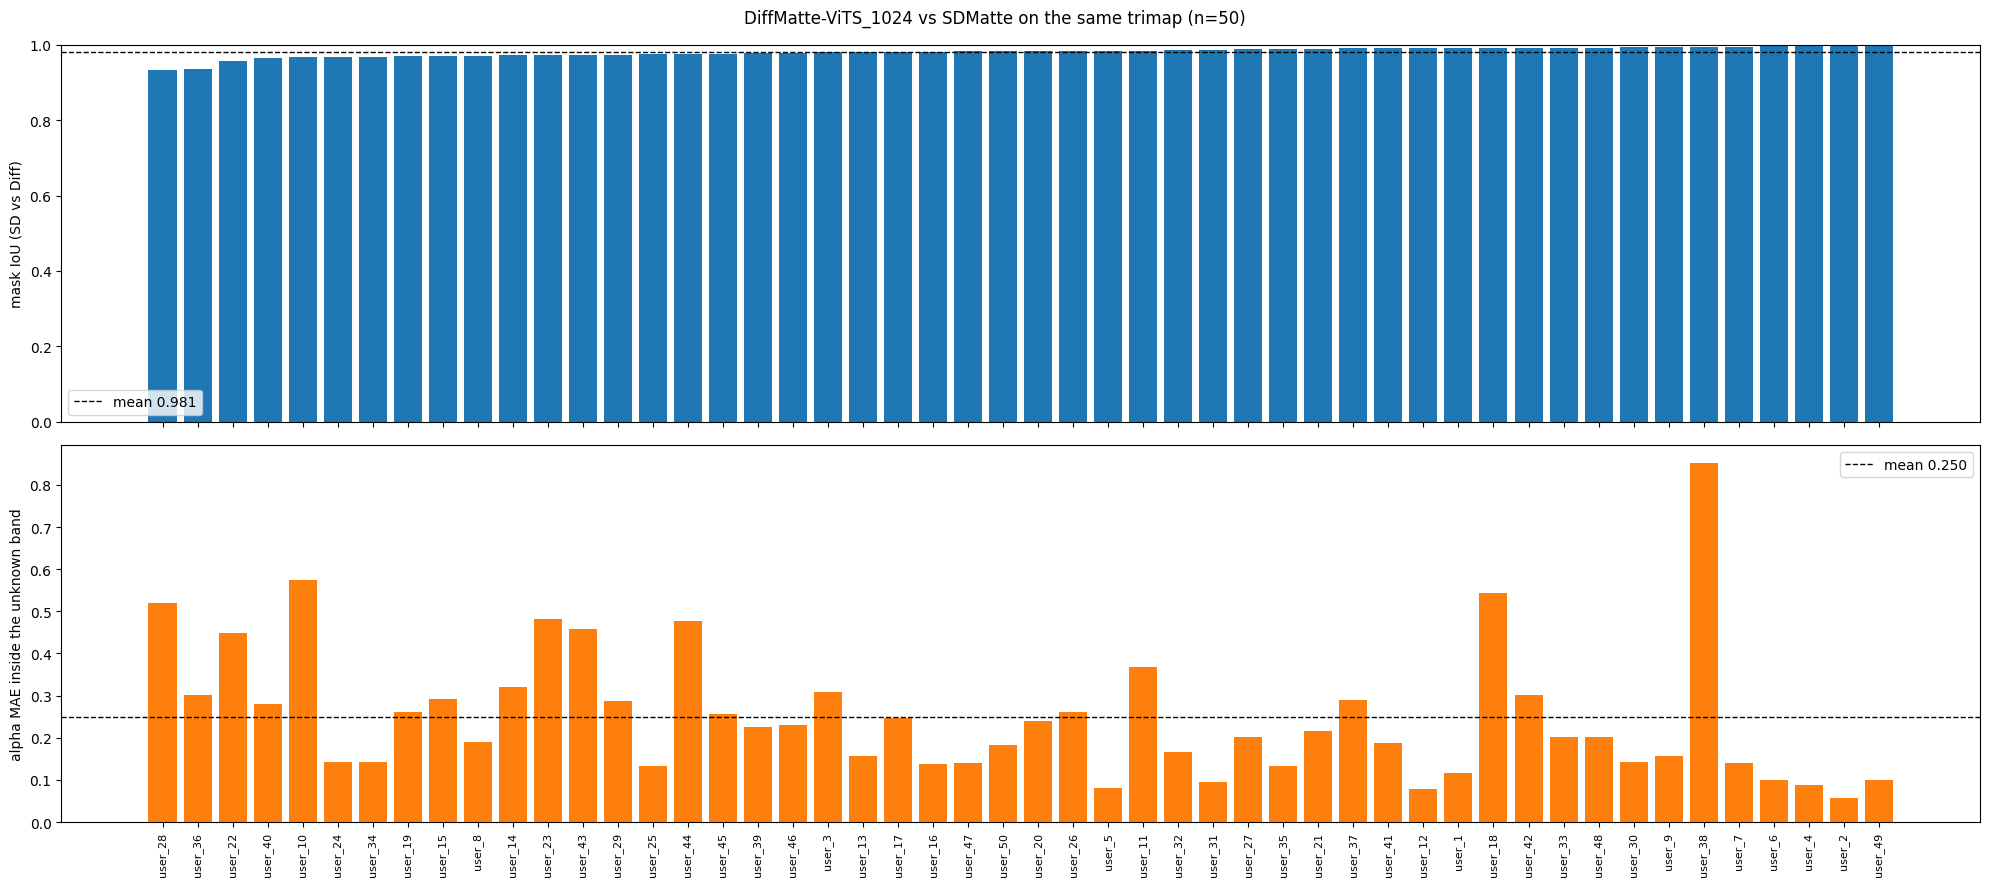

In [11]:
if rows:
    order = sorted(rows, key=lambda r: r["iou"])
    names = [r["sample"] for r in order]
    x = np.arange(len(names))

    fig, ax = plt.subplots(2, 1, figsize=(max(10, 0.4 * len(names)), 9), sharex=True)
    ax[0].bar(x, [r["iou"] for r in order], color="tab:blue")
    ax[0].axhline(np.mean([r["iou"] for r in order]), color="k", ls="--", lw=1,
                  label=f"mean {np.mean([r['iou'] for r in order]):.3f}")
    ax[0].set_ylabel("mask IoU (SD vs Diff)")
    ax[0].set_ylim(0, 1)
    ax[0].legend()

    ax[1].bar(x, [r["band_mae"] for r in order], color="tab:orange")
    ax[1].axhline(np.mean([r["band_mae"] for r in order]), color="k", ls="--", lw=1,
                  label=f"mean {np.mean([r['band_mae'] for r in order]):.3f}")
    ax[1].set_ylabel("alpha MAE inside the unknown band")
    ax[1].legend()

    ax[1].set_xticks(x)
    ax[1].set_xticklabels(names, rotation=90, fontsize=8)
    fig.suptitle(f"DiffMatte-{VARIANT} vs SDMatte on the same trimap (n={len(names)})")
    plt.tight_layout()
    fig.savefig(CMP_DIR / "_summary.png", dpi=110, bbox_inches="tight")

## Run on a single image + trimap pair (no `image2scene`)
Straight `image + trimap -> alpha` for a ready-made 0/128/255 trimap PNG, same entry point as
`run_pair` in `main_sd.py`.

ddpm sampling loop time step:   0%|          | 0/1 [00:00<?, ?it/s]

ddpm sampling loop time step: 100%|██████████| 1/1 [00:00<00:00,  7.01it/s]

ddpm sampling loop time step: 100%|██████████| 1/1 [00:00<00:00,  6.96it/s]

  diffmatte 0.2s | fg 36.6% of frame -> /home/krist/works/refine-mask/users_diff/original


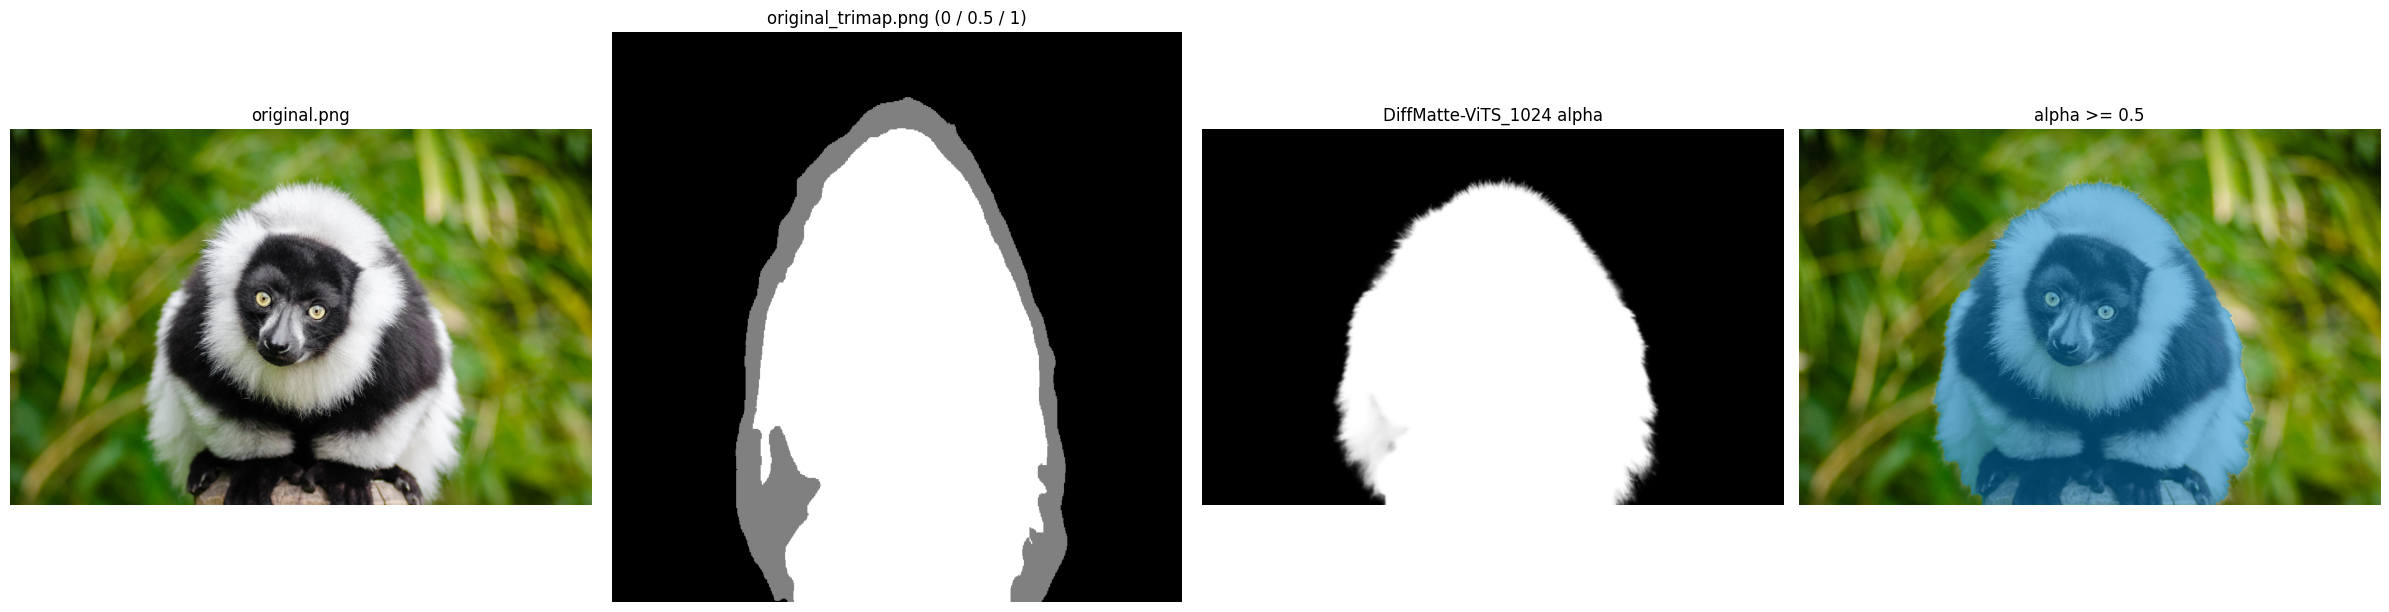

In [12]:
def run_pair(image_path, trimap_path, out_dir=None, thresh=ALPHA_THRESH):
    """DiffMatte on one (image, trimap) pair. Returns dict; writes alpha/mask/overlay to out_dir."""
    image_path, trimap_path = Path(image_path), Path(trimap_path)
    out_dir = Path(out_dir) if out_dir else OUT_DIR / image_path.stem
    out_dir.mkdir(parents=True, exist_ok=True)

    img = ImageOps.exif_transpose(Image.open(image_path)).convert("RGB")
    trimap = load_trimap_file(trimap_path)

    t0 = time.time()
    alpha = diffmatte_alpha(img, trimap)
    dt = time.time() - t0
    wall = alpha >= thresh

    Image.fromarray((alpha * 255).astype(np.uint8), "L").save(out_dir / "alpha_diffmatte.png")
    mask_to_pil(wall).save(out_dir / "mask_diffmatte.png")
    trimap_to_pil(trimap, img.size).save(out_dir / "trimap.png")
    overlay = np.asarray(img).astype(np.float32)
    overlay[wall] = 0.5 * overlay[wall] + 0.5 * np.array((0, 130, 200), np.float32)
    Image.fromarray(overlay.clip(0, 255).astype(np.uint8)).save(out_dir / "overlay.png")

    print(f"  diffmatte {dt:.1f}s | fg {100 * wall.mean():.1f}% of frame -> {out_dir}")
    return {"img": img, "alpha": alpha, "wall": wall, "trimap": trimap, "out_dir": out_dir}


pair = run_pair(ROOT / "original.png", ROOT / "original_trimap.png")

fig, ax = plt.subplots(1, 4, figsize=(24, 6))
ax[0].imshow(pair["img"]);                                      ax[0].set_title("original.png")
ax[1].imshow(pair["trimap"], cmap="gray", vmin=0, vmax=1);      ax[1].set_title("original_trimap.png (0 / 0.5 / 1)")
ax[2].imshow(pair["alpha"], cmap="gray", vmin=0, vmax=1);       ax[2].set_title(f"DiffMatte-{VARIANT} alpha")
ax[3].imshow(Image.open(pair["out_dir"] / "overlay.png"));      ax[3].set_title(f"alpha >= {ALPHA_THRESH}")
for a in ax:
    a.axis("off")
plt.tight_layout()